In [1]:
import numpy as np
from obspy.core import read, UTCDateTime
from obspy.core.inventory import read_inventory
from obspy.core.util.attribdict import AttribDict
from obspy.clients.fdsn import Client

In [2]:
# Set Client for Downloading Waveforms
client = Client("IRIS")

In [3]:
# Select Catalog around time of large event in New Zealand
# Start time is P wave arrival time according to Wilber3
starttime = UTCDateTime(2016,11,13,11,6,29)
endtime = UTCDateTime(2016,11,14,11,6,29)
cat = client.get_events(starttime=starttime -50000, endtime=endtime, minmagnitude=6.5, includearrivals=True)
print(cat)

3 Event(s) in Catalog:
2016-11-14T00:34:22.610000Z | -42.606, +173.254 | 6.5  mww
2016-11-13T11:32:08.970000Z | -42.238, +173.607 | 6.5  mww
2016-11-13T11:02:59.070000Z | -42.724, +173.065 | 7.8  Mww


In [4]:
# Get inventory that encompasses the metadata information for that time period down to the response level
inv = client.get_stations(network="AU", station="MCQ",starttime=starttime - 50000,endtime=endtime, level='response')

In [7]:
inv

Inventory created at 2026-01-28T18:29:06.259600Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?starttime=2016-11-...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (1):
			AU
		Stations (1):
			AU.MCQ (Macquarie Island)
		Channels (15):
			AU.MCQ..AX0, AU.MCQ..BHZ, AU.MCQ..BHN, AU.MCQ..BHE, AU.MCQ..LCE, 
			AU.MCQ..LCQ, AU.MCQ..VCO, AU.MCQ..VEA, AU.MCQ..VEC, AU.MCQ..VEP, 
			AU.MCQ..VKI, AU.MCQ..VMU, AU.MCQ..VMV, AU.MCQ..VMW, AU.MCQ..VPB

In [ ]:
# Get data around P arrival
st = client.get_waveforms("AU", "MCQ", "*", "*", starttime - 60, starttime + 5 * 60)

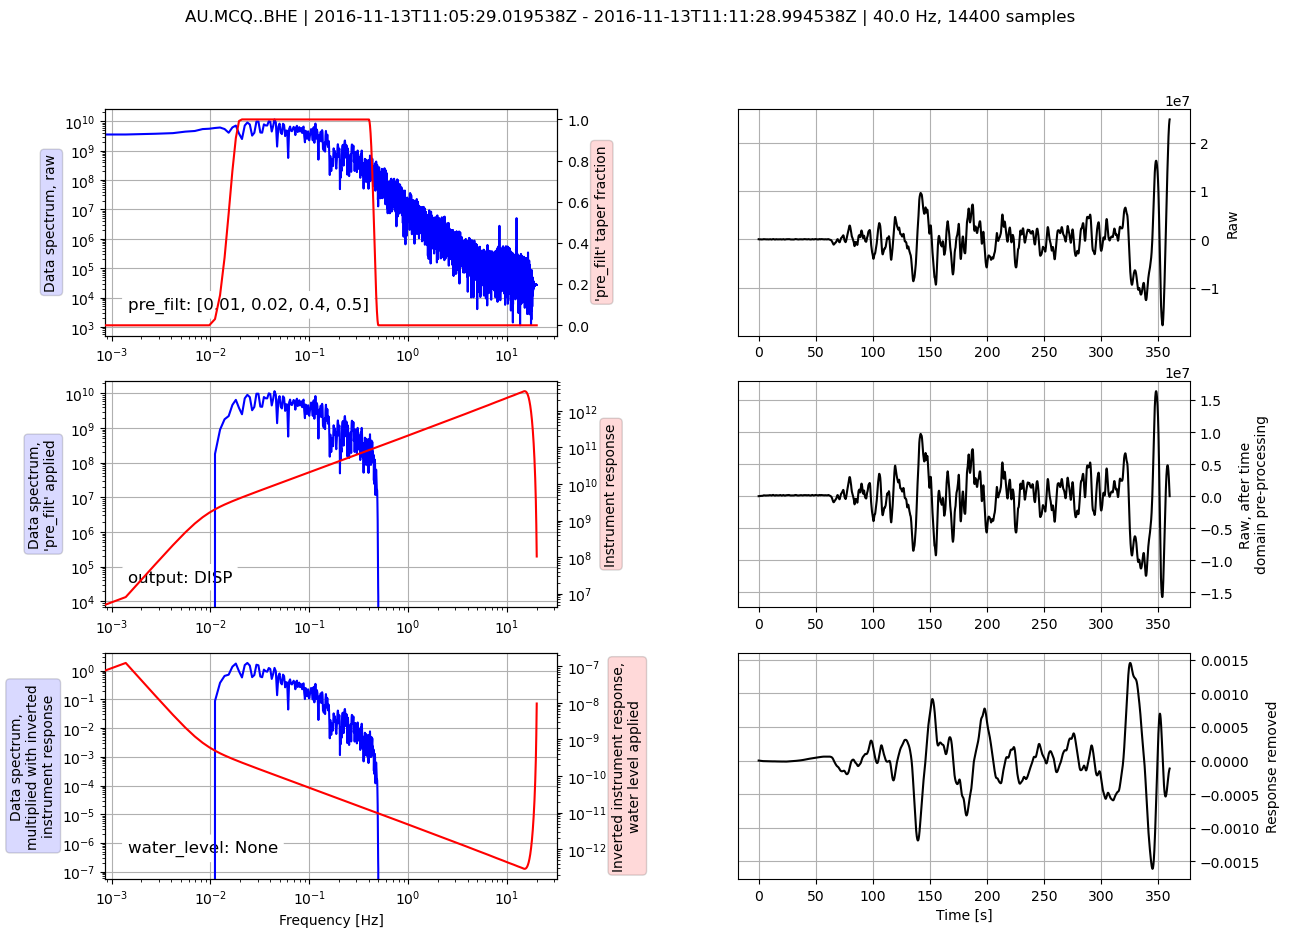

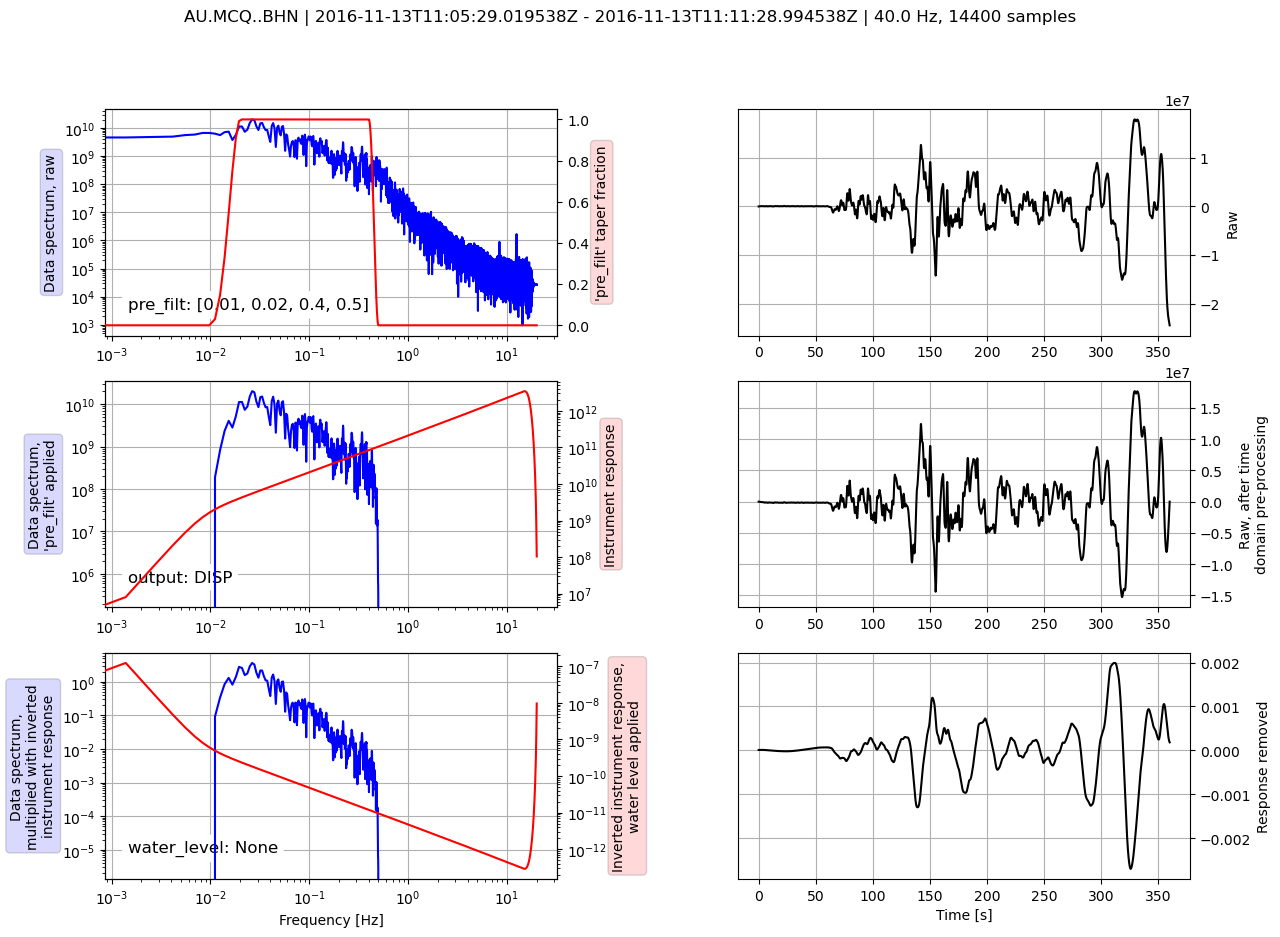

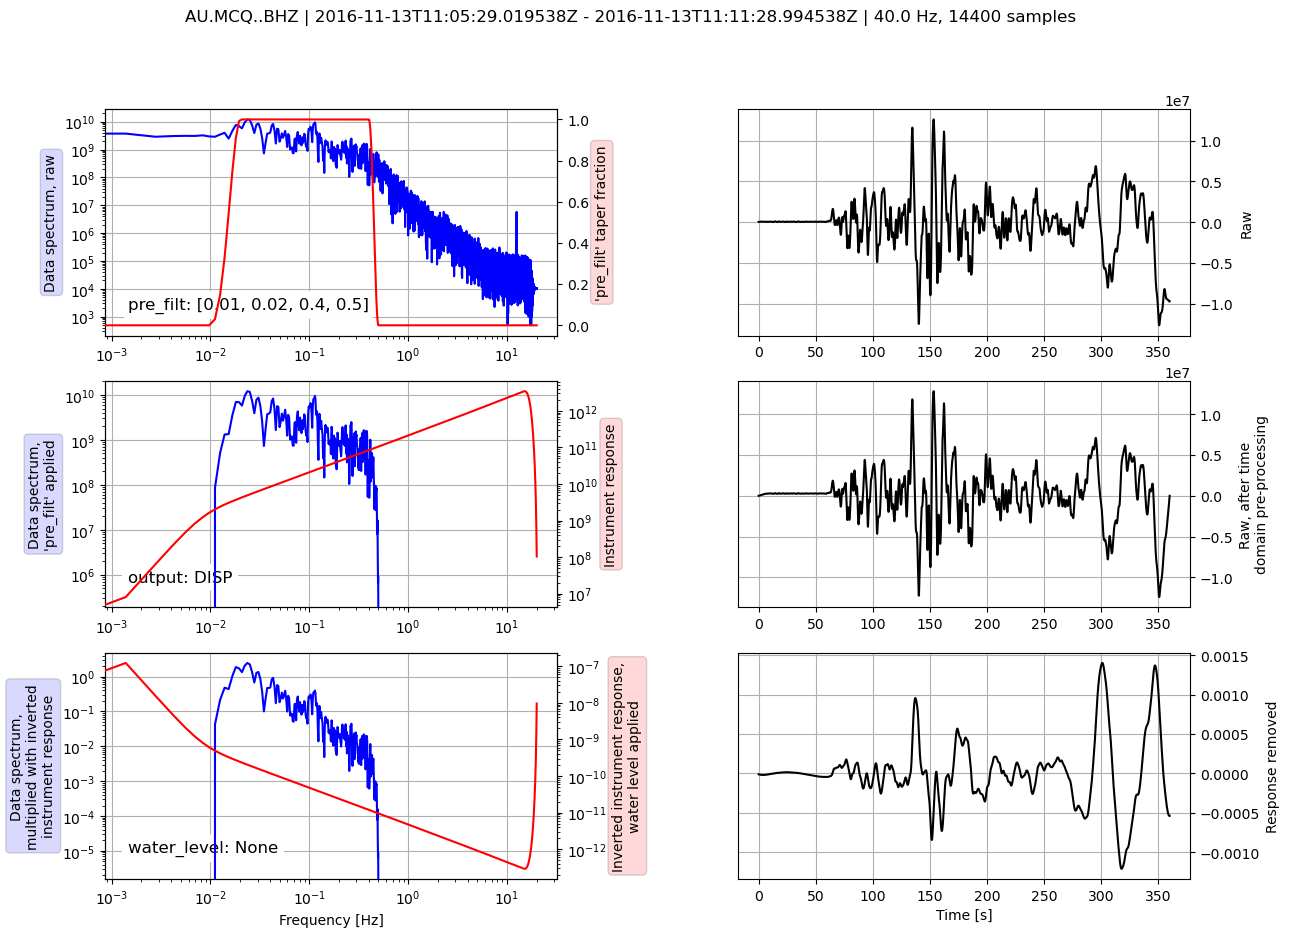

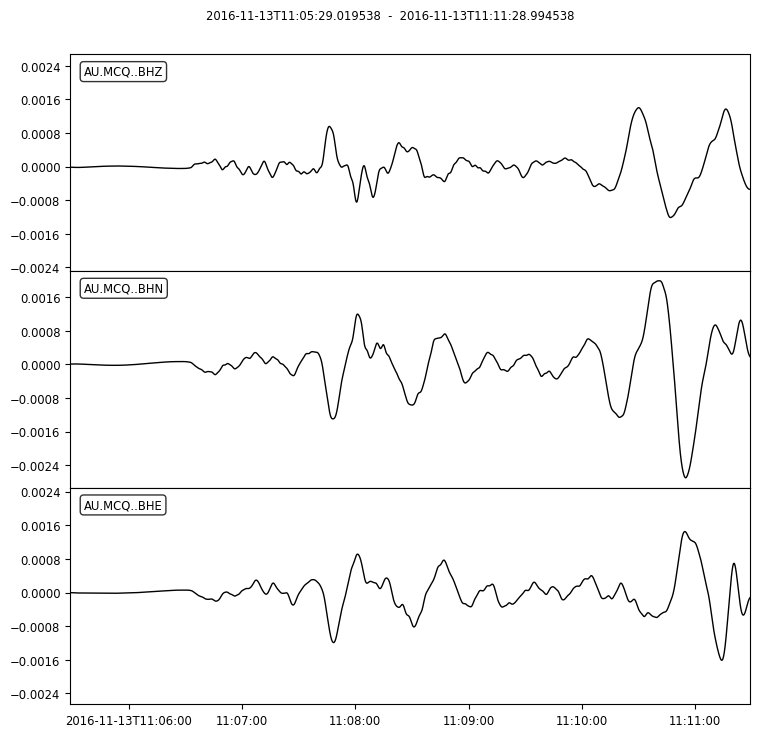

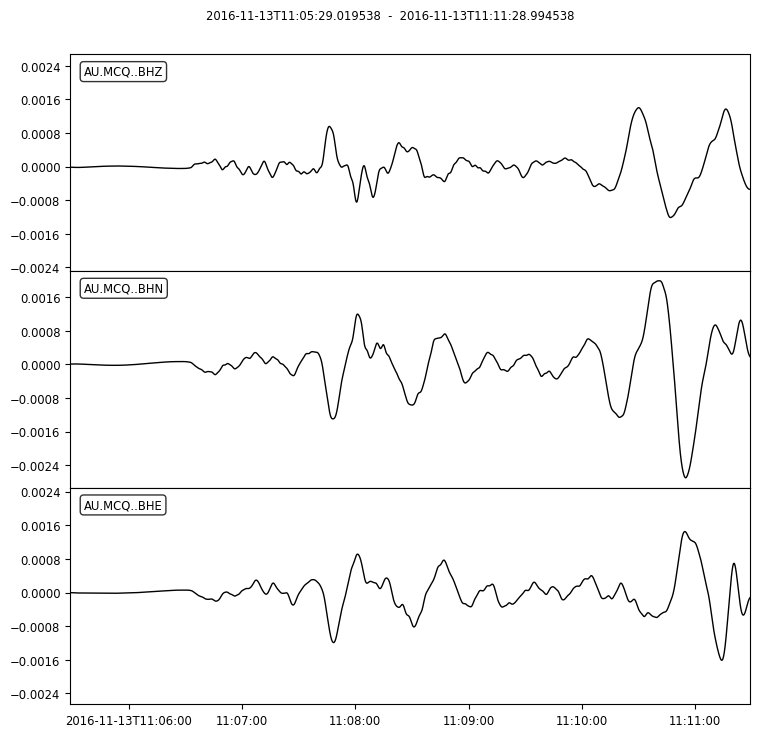

In [6]:
# Set bandpass frequencies for filter
pre_filt = (0.01,0.02,0.4,0.5)

# Remove response for each trace in stream. Optionally plot to see what is happening
for tr in st:
    tr.remove_response(inventory=inv, pre_filt=pre_filt, output='DISP', plot=True, water_level=None)

# Plot stream
st.plot()